# Bài 3 — Luật kết hợp: US Accidents

Notebook thực hiện khai phá luật kết hợp (Association Rules) trên bộ dữ liệu **US Accidents**, sử dụng tập dữ liệu giao dịch `us_accidents_association_transactions.csv` đã được chuẩn bị ở Bài 1.

Nội dung tập trung vào khảo sát dữ liệu giao dịch, so sánh Apriori và FP-Growth, lựa chọn các ngưỡng khai phá phù hợp, sinh và lọc luật kết hợp, sau đó phân tích các luật nổi bật — đặc biệt là các luật liên quan đến `MucDo_Nang`.

## 1. Nạp dữ liệu

**Đơn vị giao dịch:** 1 vụ tai nạn giao thông = 1 giao dịch (transaction).
**Item:** mỗi cột nhị phân (True/False) trong file là 1 item — item "có mặt"
trong giao dịch nếu giá trị là `True`.


In [23]:
import pandas as pd
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

DATA_PATH = '../data/processed/us_accidents/us_accidents_association_transactions.csv'

df = pd.read_csv(DATA_PATH)

# Kiểm tra dữ liệu trước khi chuyển sang dạng boolean.
if not df.dtypes.eq(bool).all():
    unique_values = set(df.stack().dropna().unique())
    if unique_values <= {0, 1, False, True}:
        df = df.astype(bool)
    else:
        raise ValueError('Dữ liệu transaction phải chỉ chứa True/False hoặc 0/1.')

print("Số giao dịch (vụ tai nạn):", df.shape[0])
print("Số item (thuộc tính nhị phân):", df.shape[1])
df.head()

Số giao dịch (vụ tai nạn): 80000
Số item (thuộc tính nhị phân): 32


,Amenity,Crossing,Give_Way,Junction,No_Exit,Railway,Station,Stop,Traffic_Signal,GioTrongNgay_Dem,...,ThoiTiet_Mua,ThoiTiet_Nhieu_May,ThoiTiet_Quang_Dang,ThoiTiet_Suong_Mu,ThoiTiet_Tuyet_Bang,ThoiTiet_Unknown,AnhSang_Day,AnhSang_Night,MucDo_Nang,MucDo_Nhe
0,False,True,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,True
4,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,True,False


## 2. Nhắc lại cách rời rạc hóa / tạo giao dịch (đã làm ở Bài 1)

File `us_accidents_association_transactions.csv` được sinh ra ở
`khao-sat.ipynb` (Mục 3.5.3) bằng cách gộp **7 nhóm item** cho mỗi vụ tai nạn:

| Nhóm | Nguồn | Cách rời rạc hóa |
|---|---|---|
| Cờ hạ tầng | `Crossing`, `Junction`, `Traffic_Signal`, `Railway`, `Station`, `Stop`, `Amenity`, `Give_Way`, `No_Exit`... | Đã có sẵn dạng nhị phân True/False trong dữ liệu gốc, giữ nguyên. |
| Khung giờ | `Hour_of_Day` | Chia thành `Sang` (5–10h), `Trua_Chieu` (11–16h), `Toi` (17–20h), `Dem` (21–4h) và `Unknown` nếu thiếu dữ liệu. |
| Loại ngày | `Is_Weekend` | Nhị phân hóa thành `LoaiNgay_CuoiTuan` / `LoaiNgay_NgayThuong`. |
| Nhóm nhiệt độ | `Temperature_Bin` | Sử dụng các nhóm nhiệt độ đã rời rạc hóa ở Bài 1: `Rat_lanh`, `Lanh`, `Vua`, `Nong`, `Unknown`. |
| Nhóm thời tiết | `Weather_Condition` | Gộp hàng chục giá trị text gốc thành nhóm lớn: `Quang_Dang`, `Nhieu_May`, `Mua`, `Bao`, `Suong_Mu`, `Tuyet_Bang`, `Unknown`. |
| Ánh sáng | `Sunrise_Sunset` | `AnhSang_Day` / `AnhSang_Night`. |
| Mức độ nghiêm trọng | `Severity` (1–4) | Gộp về 2 nhóm: `MucDo_Nhe` (Severity 1–2), `MucDo_Nang` (Severity 3–4). |

**Lý do phải bổ sung thêm 6 nhóm item ngoài cờ hạ tầng:** khảo sát thực tế ở
Bài 1 cho thấy nếu chỉ dùng 12–13 cờ hạ tầng làm item thì hơn 92% giao dịch chỉ
có 0–1 item (đa số cờ hạ tầng rất hiếm, ví dụ `Roundabout` gần như luôn
`False`) — không đủ để Apriori/FP-Growth sinh luật 2 vế có ý nghĩa. Việc bổ
sung các nhóm thời gian, loại ngày, nhiệt độ, thời tiết, ánh sáng và mức độ
nghiêm trọng giúp mỗi giao dịch có tối thiểu 5 item, phù hợp hơn cho khai phá.

## 3. Khảo sát nhanh giao dịch

Trước khi chọn ngưỡng, cần biết: mỗi giao dịch có trung bình bao nhiêu item,
và item nào phổ biến/hiếm để lường trước những luật "tầm thường" (support/
confidence cao chỉ vì item luôn xuất hiện).


### 3.1. Kích thước giao dịch

In [24]:
transaction_sizes = df.sum(axis=1)
print("Số item / giao dịch:")
print(transaction_sizes.describe())
print("\nTỷ lệ giao dịch có >= 2 item:", round((transaction_sizes >= 2).mean() * 100, 2), "%")

Số item / giao dịch:
count    80000.000000
mean         6.365263
std          0.675815
min          5.000000
25%          6.000000
50%          6.000000
75%          7.000000
max         11.000000
dtype: float64

Tỷ lệ giao dịch có >= 2 item: 100.0 %


### 3.2. Độ phổ biến của item

In [25]:
item_support = df.mean().sort_values(ascending=False)

print("=== 10 item PHỔ BIẾN nhất (dễ tạo luật tầm thường) ===")
print(item_support.head(10).round(4))

print("\n=== 10 item HIẾM nhất ===")
print(item_support.tail(10).round(4))

print("\nSupport của 2 item mức độ nghiêm trọng:")
print(item_support[['MucDo_Nhe', 'MucDo_Nang']])

=== 10 item PHỔ BIẾN nhất (dễ tạo luật tầm thường) ===
LoaiNgay_NgayThuong        0.8354
MucDo_Nhe                  0.8232
AnhSang_Day                0.6701
ThoiTiet_Quang_Dang        0.5454
NhietDo_Vua                0.4442
NhietDo_Lanh               0.3595
ThoiTiet_Nhieu_May         0.3369
AnhSang_Night              0.3293
GioTrongNgay_Trua_Chieu    0.3067
GioTrongNgay_Sang          0.2803
dtype: float64

=== 10 item HIẾM nhất ===
Station                0.0238
NhietDo_Unknown        0.0228
ThoiTiet_Unknown       0.0207
Amenity                0.0103
NhietDo_Rat_lanh       0.0102
Railway                0.0098
Give_Way               0.0039
ThoiTiet_Bao           0.0027
ThoiTiet_Tuyet_Bang    0.0018
No_Exit                0.0012
dtype: float64

Support của 2 item mức độ nghiêm trọng:
MucDo_Nhe     0.823175
MucDo_Nang    0.176825
dtype: float64


### 3.3. Kiểm tra tính one-hot theo từng nhóm item

Theo thiết kế ở Bài 1, mỗi giao dịch thường có đúng một item thuộc mỗi nhóm
đã được rời rạc hóa: khung giờ, loại ngày, nhiệt độ, thời tiết, ánh sáng và
mức độ nghiêm trọng. Kiểm tra này giúp phát hiện giao dịch bị thiếu hoặc có
nhiều item cùng bật trong một nhóm. Riêng các cờ hạ tầng không bắt buộc
one-hot vì một vụ tai nạn có thể đồng thời có nhiều điều kiện hạ tầng.

In [26]:
group_prefixes = {
    'Khung giờ': 'GioTrongNgay_',
    'Loại ngày': 'LoaiNgay_',
    'Nhiệt độ': 'NhietDo_',
    'Thời tiết': 'ThoiTiet_',
    'Ánh sáng': 'AnhSang_',
    'Mức độ nghiêm trọng': 'MucDo_',
}

# Cờ hạ tầng không có prefix chung và không yêu cầu one-hot.
other_prefixes = tuple(group_prefixes.values())
infra_cols = [c for c in df.columns if not c.startswith(other_prefixes)]

groups = {'Cờ hạ tầng (không bắt buộc one-hot)': infra_cols}
for group_name, prefix in group_prefixes.items():
    groups[group_name] = [c for c in df.columns if c.startswith(prefix)]

for group_name, columns in groups.items():
    counts = df[columns].sum(axis=1)
    print(f'\n{group_name} ({len(columns)} cột):')
    print(counts.value_counts().sort_index())


Cờ hạ tầng (không bắt buộc one-hot) (9 cột):
0    57900
1    16339
2     4483
3     1099
4      164
5       15
Name: count, dtype: int64

Khung giờ (5 cột):
1    80000
Name: count, dtype: int64

Loại ngày (2 cột):
1    80000
Name: count, dtype: int64

Nhiệt độ (5 cột):
1    80000
Name: count, dtype: int64

Thời tiết (7 cột):
0       61
1    79939
Name: count, dtype: int64

Ánh sáng (2 cột):
0       51
1    79949
Name: count, dtype: int64

Mức độ nghiêm trọng (2 cột):
1    80000
Name: count, dtype: int64


**Nhận xét:** các nhóm khung giờ, loại ngày, nhiệt độ và mức độ nghiêm trọng
phải có đúng 1 item bật trong mỗi giao dịch. Dữ liệu hiện tại xác nhận điều đó.
Riêng thời tiết có 61 giao dịch và ánh sáng có 51 giao dịch không có item,
cho thấy còn thiếu dữ liệu ở hai nhóm này; không tự ý gán giá trị vì notebook
đang phân tích file đã tiền xử lý.

**Nhận xét:** `LoaiNgay_NgayThuong` (83.5%), `MucDo_Nhe` (82.3%), `AnhSang_Day`
(67%) có support rất cao — bất kỳ luật nào chứa các item này gần như luôn đạt
support/confidence cao một cách "tầm thường" (vì chúng gần như luôn đúng, bất
kể vế còn lại là gì). Đây là lý do bước 5 bên dưới **bắt buộc lọc bằng
`lift`**: lift đo mức độ hai item xuất hiện cùng nhau **nhiều hơn mức ngẫu
nhiên dự kiến** — lift ≈ 1 nghĩa là hai item độc lập, luật không mang thông
tin gì thêm ngoài việc mỗi item đã phổ biến sẵn.


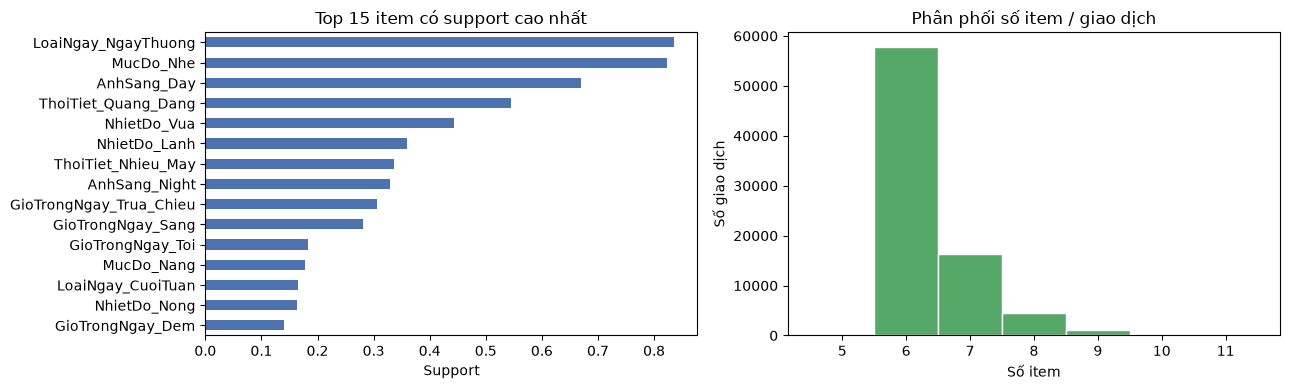

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

item_support.head(15).sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 15 item có support cao nhất')
axes[0].set_xlabel('Support')

axes[1].hist(transaction_sizes, bins=range(5, transaction_sizes.max()+2),
             color='#55A868', edgecolor='white', align='left')
axes[1].set_title('Phân phối số item / giao dịch')
axes[1].set_xlabel('Số item')
axes[1].set_ylabel('Số giao dịch')

plt.tight_layout()
plt.show()

## 4. So sánh thuật toán (Apriori vs FP-Growth) và ngưỡng `min_support`

Theo yêu cầu đề bài: nếu chỉ dùng 1 thuật toán thì phải so sánh ≥ 2 cấu hình
ngưỡng. Ở đây nhóm làm cả hai: so sánh **thuật toán** (tốc độ) và so sánh
**ngưỡng min_support** (số tập phổ biến sinh ra).


**Giả định và cơ chế của từng thuật toán (theo cách hiểu của nhóm):**

- **Apriori** dựa trên *tính chất Apriori (Apriori property / downward closure)*:
  nếu một tập mục là phổ biến thì **mọi tập con** của nó cũng phải phổ biến —
  suy ra chiều ngược lại: nếu một tập mục **không** phổ biến thì mọi tập cha
  chứa nó cũng không thể phổ biến, nên có thể loại bỏ sớm. Thuật toán duyệt
  theo từng mức (level-wise): ở bước k, nó ghép các tập phổ biến kích thước
  k−1 lại để **sinh ứng viên** kích thước k, sau đó quét lại toàn bộ giao
  dịch để đếm support của từng ứng viên và loại ứng viên không đạt ngưỡng.
  Nhược điểm: khi số item lớn và ngưỡng `min_support` thấp, số ứng viên sinh
  ra có thể bùng nổ, và mỗi mức đều cần quét lại dữ liệu.
- **FP-Growth** không sinh ứng viên tường minh. Nó chỉ quét dữ liệu 2 lần:
  lần 1 để đếm support từng item đơn và loại item không đạt ngưỡng, lần 2 để
  nén các giao dịch (đã sắp theo support giảm dần) vào một cấu trúc cây dùng
  chung tiền tố gọi là **FP-tree**. Sau đó, thuật toán khai thác tập phổ biến
  bằng cách đệ quy: với mỗi item, xây một "cây điều kiện" (conditional
  FP-tree) chỉ chứa các giao dịch có item đó, rồi tìm tập phổ biến trong cây
  con nhỏ hơn này. Nhờ không phải sinh và đếm lại hàng loạt ứng viên, FP-Growth
  thường hiệu quả hơn Apriori khi dữ liệu **dày đặc** (nhiều item/giao dịch) —
  đúng với đặc điểm bộ dữ liệu này (trung bình 6,37 item/giao dịch).

Cả hai đều là thuật toán **chính xác** (exact), không xấp xỉ: nếu cùng chạy ở
cùng `min_support`, chúng phải trả về **đúng cùng một tập** các tập phổ biến —
nhóm sẽ kiểm chứng điều này ở ô bên dưới trước khi kết luận về tốc độ.

In [28]:
results = []

for algo_name, algo_fn in [('Apriori', apriori), ('FP-Growth', fpgrowth)]:
    for ms in [0.01, 0.03]:
        t0 = time.time()
        freq = algo_fn(df, min_support=ms, use_colnames=True)
        elapsed = time.time() - t0
        results.append({
            'Thuật toán': algo_name,
            'min_support': ms,
            'Số tập phổ biến': len(freq),
            'Thời gian (giây)': round(elapsed, 3)
        })

compare_df = pd.DataFrame(results)
compare_df

,Thuật toán,min_support,Số tập phổ biến,Thời gian (giây)
0,Apriori,0.01,1504,0.632
1,Apriori,0.03,572,0.227
2,FP-Growth,0.01,1504,0.526
3,FP-Growth,0.03,572,0.480


In [29]:
# Kiểm chứng: Apriori và FP-Growth có thực sự trả về CÙNG một tập kết quả
# (không chỉ cùng SỐ LƯỢNG) ở cùng một min_support hay không.
check_support = 0.01
freq_ap_check = apriori(df, min_support=check_support, use_colnames=True)
freq_fp_check = fpgrowth(df, min_support=check_support, use_colnames=True)

itemsets_ap = set(freq_ap_check['itemsets'].apply(frozenset))
itemsets_fp = set(freq_fp_check['itemsets'].apply(frozenset))

print(f"min_support = {check_support}")
print("Số tập phổ biến (Apriori) :", len(itemsets_ap))
print("Số tập phổ biến (FP-Growth):", len(itemsets_fp))
print("Hai tập kết quả có giống hệt nhau không:", itemsets_ap == itemsets_fp)

min_support = 0.01
Số tập phổ biến (Apriori) : 1504
Số tập phổ biến (FP-Growth): 1504
Hai tập kết quả có giống hệt nhau không: True


**Nhận xét:** hai thuật toán trả về **đúng cùng một tập** các tập phổ biến —
đúng như kỳ vọng lý thuyết (cả hai đều là thuật toán chính xác). Sự khác biệt
duy nhất giữa chúng là **cách tìm ra kết quả đó** và **tốc độ**, không phải
chất lượng kết quả.

**Nhận xét kỹ thuật:**
- Với 80.000 giao dịch × 32 item (mật độ vừa phải), cả hai thuật toán đều chạy dưới vài giây trong lần thử nghiệm này. Dữ liệu không đủ lớn để đại diện cho thời gian chạy trên toàn bộ dữ liệu gốc 2,3 triệu dòng.
- `min_support = 0.01` (1%) sinh ra **nhiều tập phổ biến hơn hẳn** so với `min_support = 0.03` (3%), vì ngưỡng thấp hơn cho phép giữ lại các tổ hợp ít phổ biến hơn.
- Ở `min_support = 0.01`, FP-Growth chạy nhanh hơn Apriori trong lần đo này. Tuy nhiên, ở `min_support = 0.03`, Apriori lại nhanh hơn. Do đó không thể kết luận FP-Growth luôn nhanh hơn; nhóm chọn FP-Growth cho bước khai phá chính vì nó có lợi thế ở ngưỡng 1% đang sử dụng.
- **Chọn `min_support = 0.01`** vì tương đương ít nhất 800 giao dịch trong 80.000, đủ thấp để giữ các tổ hợp có thể liên quan đến item ít phổ biến nhưng vẫn hạn chế các luật quá hiếm và khó diễn giải.

## 5. Sinh luật kết hợp

- Sinh tập phổ biến với `min_support = 0.01`.
- Sinh luật với `min_confidence = 0.2` — cố tình để **thấp** ở bước sinh luật vì `MucDo_Nang` chỉ có support 17.7% (lớp thiểu số so với `MucDo_Nhe` 82.3%), nên các luật liên quan đến nó có thể khó đạt confidence cao dù lift lớn hơn 1.
- Lọc `lift > 1.2` để ưu tiên các luật có liên hệ dương rõ hơn về mặt đồng xuất hiện. Lift không tự chứng minh ý nghĩa thống kê hoặc quan hệ nhân quả.
- Các luật chứa item `Unknown` được giữ riêng để phát hiện hiện tượng thiếu dữ liệu đồng thời, nhưng không dùng làm insight nghiệp vụ.

In [30]:
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.2
MIN_LIFT = 1.2

freq_itemsets = fpgrowth(df, min_support=MIN_SUPPORT, use_colnames=True)
print("Số tập phổ biến:", len(freq_itemsets))

rules = association_rules(
    freq_itemsets, metric="confidence",
    min_threshold=MIN_CONFIDENCE, num_itemsets=len(freq_itemsets)
)
print("Số luật (trước lọc lift):", len(rules))

rules = rules[rules['lift'] > MIN_LIFT].copy()
print(f"Số luật sau lọc lift > {MIN_LIFT}:", len(rules))

rules['antecedents_str'] = rules['antecedents'].apply(lambda x: frozenset(x))
rules['consequents_str'] = rules['consequents'].apply(lambda x: frozenset(x))

Số tập phổ biến: 1504
Số luật (trước lọc lift): 9577
Số luật sau lọc lift > 1.2: 4244


### Lọc luật có tính dư thừa theo tiêu chí confidence

Trong notebook này, một luật được xem là **có tính dư thừa** nếu đã có một luật "tổng quát hơn" (vế trái là tập con của luật này, cùng vế phải) với confidence **bằng hoặc cao hơn** — khi đó thêm điều kiện vào vế trái không giúp dự đoán tốt hơn theo tiêu chí đã chọn.

Sau bước này, các luật chứa item `Unknown` cũng được loại riêng khỏi tập `rules_business` để phục vụ phân tích nghiệp vụ; các luật đó vẫn được giữ trong `rules_clean` nhằm phát hiện vấn đề chất lượng dữ liệu.

In [31]:
def filter_redundant_rules(rules_df):
    """Loại luật dư thừa theo tiêu chí confidence do nhóm lựa chọn."""
    rules_df = rules_df.copy()
    rules_df['ante_len'] = rules_df['antecedents_str'].apply(len)
    rules_df = rules_df.sort_values('ante_len')

    kept = []
    for rule in rules_df.to_dict('records'):
        is_redundant = False
        for kept_rule in kept:
            if (kept_rule['consequents_str'] == rule['consequents_str']
                    and kept_rule['antecedents_str'] < rule['antecedents_str']
                    and kept_rule['confidence'] >= rule['confidence'] - 1e-9):
                is_redundant = True
                break
        if not is_redundant:
            kept.append(rule)
    return pd.DataFrame(kept).drop(columns=['ante_len'])

rules_clean = filter_redundant_rules(rules)

# Giữ luật Unknown trong rules_clean để phát hiện vấn đề dữ liệu,
# nhưng loại chúng khỏi tập luật dùng cho diễn giải nghiệp vụ.
def contains_unknown(itemset):
    return any('Unknown' in item for item in itemset)

rules_business = rules_clean[
    ~rules_clean['antecedents_str'].apply(contains_unknown)
    & ~rules_clean['consequents_str'].apply(contains_unknown)
].copy()

print("Số luật trước khi lọc dư thừa:", len(rules))
print("Số luật sau khi lọc dư thừa:  ", len(rules_clean))
print("Số luật không chứa Unknown:    ", len(rules_business))

Số luật trước khi lọc dư thừa: 4244
Số luật sau khi lọc dư thừa:   2323
Số luật không chứa Unknown:     2178


## 6. Các luật nổi bật

### 6.1. Luật liên quan `MucDo_Nang` (mức độ nghiêm trọng cao)

Đây là hướng khai phá có giá trị kỹ thuật rõ ràng nhất của bộ dữ liệu này:
tìm điều kiện (hạ tầng, thời gian, thời tiết) đi kèm với tai nạn **mức độ
nghiêm trọng cao**.


In [32]:
severity_rules = rules_business[
    rules_business['consequents_str'] == frozenset({'MucDo_Nang'})
].sort_values('lift', ascending=False)

print("Số luật nghiệp vụ (X -> MucDo_Nang):", len(severity_rules))

top_severity = severity_rules[['antecedents_str', 'support', 'confidence', 'lift']].head(10)
top_severity.columns = ['Vế trái (điều kiện)', 'Support', 'Confidence', 'Lift']
top_severity

Số luật nghiệp vụ (X -> MucDo_Nang): 29


,Vế trái (điều kiện),Support,Confidence,Lift
726,"frozenset({NhietDo_Vua, Junction})",0.011100,0.266747,1.508535
1858,"frozenset({NhietDo_Vua, LoaiNgay_CuoiTuan, Anh...",0.012162,0.258845,1.463851
759,"frozenset({LoaiNgay_CuoiTuan, ThoiTiet_Nhieu_M...",0.012850,0.254518,1.439380
2042,"frozenset({NhietDo_Vua, ThoiTiet_Nhieu_May, Gi...",0.013288,0.253699,1.434748
763,"frozenset({NhietDo_Vua, LoaiNgay_CuoiTuan})",0.017163,0.245354,1.387552
727,"frozenset({Junction, AnhSang_Day})",0.014900,0.243166,1.375179
2112,"frozenset({NhietDo_Vua, ThoiTiet_Nhieu_May, Gi...",0.011813,0.242370,1.370676
2049,"frozenset({NhietDo_Vua, ThoiTiet_Nhieu_May, Gi...",0.011825,0.241635,1.366519
152,frozenset({Junction}),0.021925,0.239225,1.352893
1861,"frozenset({LoaiNgay_CuoiTuan, GioTrongNgay_Tru...",0.013550,0.238242,1.347331


**Đọc luật ví dụ (dòng đầu tiên):** `{Junction, NhietDo_Vua} -> MucDo_Nang` với support ≈ 1.1%, confidence ≈ 26.7%, lift ≈ 1.51.

- **Support 1.1%**: khoảng 1,1% trong tổng số 80.000 vụ tai nạn có đồng thời `Junction`, `NhietDo_Vua` và `MucDo_Nang`.
- **Confidence 26.7%**: trong các vụ tai nạn có `Junction` và `NhietDo_Vua`, 26.7% có mức độ nghiêm trọng cao — cao hơn tỷ lệ nền của `MucDo_Nang` trong toàn bộ dữ liệu (17.7%).
- **Lift ≈ 1.51**: xác suất xuất hiện `MucDo_Nang` khi có hai điều kiện này cao khoảng **1,51 lần** so với xác suất nền. Lift lớn hơn 1 cho thấy mối liên hệ dương về mặt đồng xuất hiện; chỉ số này không tự chứng minh ý nghĩa thống kê hay quan hệ nhân quả.

**Lưu ý về độ mạnh của luật:** lift ≈ 1,51 của luật `{Junction, NhietDo_Vua}
→ MucDo_Nang` là **luật mạnh nhất** trong nhóm 29 luật nghiệp vụ hướng tới
`MucDo_Nang` (xem bảng trên) — phần lớn các luật còn lại có lift trong khoảng
1,2–1,4. Đây là mức tương quan **tồn tại nhưng không quá mạnh**: các điều kiện
hạ tầng/thời tiết/thời gian đơn lẻ hoặc kết hợp 2–3 yếu tố chỉ làm tăng khả
năng tai nạn nặng khoảng 20–50% so với ngẫu nhiên, không phải yếu tố quyết
định. Điều này khớp với nhận xét thường gặp ở Bài 2 (phân lớp `Severity`) rằng
mức độ nghiêm trọng khó dự đoán chính xác chỉ từ một vài đặc trưng rời rạc.

### 6.1.b. Đối chứng: luật liên quan `MucDo_Nhe`

Để có góc nhìn cân đối, nhóm xem thêm các luật dẫn tới `MucDo_Nhe` (mức độ
nhẹ) trong cùng tập `rules_business`.

In [33]:
mild_rules = rules_business[
    rules_business['consequents_str'] == frozenset({'MucDo_Nhe'})
].sort_values('lift', ascending=False)

print("Số luật nghiệp vụ (X -> MucDo_Nhe):", len(mild_rules))

top_mild = mild_rules[['antecedents_str', 'support', 'confidence', 'lift']].head(8)
top_mild.columns = ['Vế trái (điều kiện)', 'Support', 'Confidence', 'Lift']
top_mild

Số luật nghiệp vụ (X -> MucDo_Nhe): 0


,Vế trái (điều kiện),Support,Confidence,Lift


**Nhận xét (kết quả 0 luật là một phát hiện có ý nghĩa, không phải lỗi):**
sau khi loại các luật chứa `Unknown`, **không có luật nào** dẫn tới `MucDo_Nhe`
đạt `lift > 1,2`. Điều này khớp với lý thuyết: `MucDo_Nhe` đã chiếm tới 82,3%
nền, nên với ngưỡng lift 1,2, confidence của luật phải vượt 1,2 × 0,823 ≈ 98,8%
mới đạt — gần như không điều kiện thực tế nào (ngoài các cờ `Unknown` đã bị
loại) đẩy được xác suất mức nhẹ lên cao đến vậy. Ngược lại, `MucDo_Nang` chỉ
chiếm 17,7% nền nên dư địa để lift vượt 1,2 dễ hơn nhiều (chỉ cần confidence
> 21,2%). Đây là lý do kỹ thuật cốt lõi giải thích vì sao nhóm luật liên quan
`MucDo_Nang` giàu phát hiện hơn hẳn, và vì sao đề bài/README gợi ý ưu tiên
hướng khai phá `MucDo_Nang` khi làm bộ dữ liệu này.

### 6.2. Top luật nổi bật nhất theo lift (toàn bộ, không giới hạn vế phải)


In [34]:
top_overall = rules_clean.sort_values('lift', ascending=False)[
    ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
].head(10)
top_overall.columns = ['Vế trái', 'Vế phải', 'Support', 'Confidence', 'Lift']
top_overall

,Vế trái,Vế phải,Support,Confidence,Lift
299,frozenset({ThoiTiet_Unknown}),"frozenset({NhietDo_Unknown, AnhSang_Day})",0.011437,0.553539,39.258087
1161,"frozenset({NhietDo_Unknown, AnhSang_Day})",frozenset({ThoiTiet_Unknown}),0.011437,0.811170,39.258087
46,frozenset({ThoiTiet_Unknown}),"frozenset({MucDo_Nhe, LoaiNgay_NgayThuong, Nhi...",0.011750,0.568663,39.016332
2094,"frozenset({MucDo_Nhe, LoaiNgay_NgayThuong, Nhi...",frozenset({ThoiTiet_Unknown}),0.011750,0.806175,39.016332
60,frozenset({ThoiTiet_Unknown}),"frozenset({MucDo_Nhe, NhietDo_Unknown})",0.014863,0.719298,38.933599
1231,"frozenset({MucDo_Nhe, NhietDo_Unknown})",frozenset({ThoiTiet_Unknown}),0.014863,0.804465,38.933599
297,frozenset({ThoiTiet_Unknown}),"frozenset({LoaiNgay_NgayThuong, NhietDo_Unknown})",0.014550,0.704174,38.584889
1296,"frozenset({LoaiNgay_NgayThuong, NhietDo_Unknown})",frozenset({ThoiTiet_Unknown}),0.014550,0.797260,38.584889
43,frozenset({ThoiTiet_Unknown}),frozenset({NhietDo_Unknown}),0.018187,0.880218,38.521566
42,frozenset({NhietDo_Unknown}),frozenset({ThoiTiet_Unknown}),0.018187,0.795952,38.521566


**Nhận xét:** nhóm luật có lift cao nhất (lift ≈ 38–39) chủ yếu xoay quanh các item `..._Unknown` (`ThoiTiet_Unknown`, `NhietDo_Unknown`) xuất hiện cùng nhau. Đây không phải phát hiện nghiệp vụ về tai nạn mà phản ánh việc hai thuộc tính bị thiếu dữ liệu có xu hướng đồng xuất hiện. Nguyên nhân cụ thể không thể xác định chỉ từ kết quả luật kết hợp. Vì vậy, các luật `Unknown` được giữ lại để phát hiện vấn đề chất lượng dữ liệu nhưng được loại khỏi `rules_business`, là tập dùng cho các diễn giải nghiệp vụ.

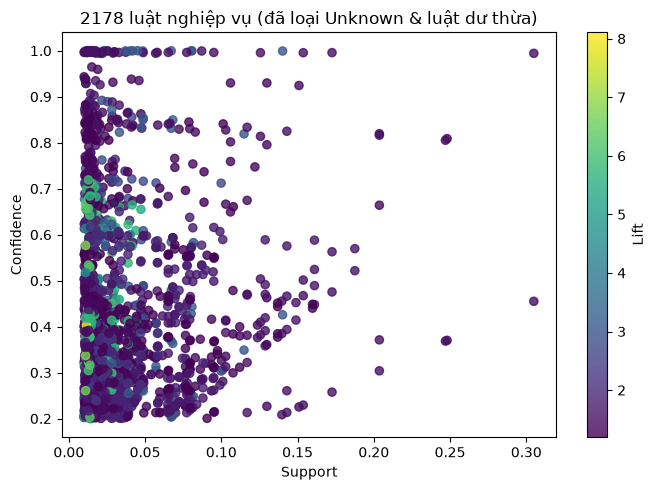

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(rules_business['support'], rules_business['confidence'],
                 c=rules_business['lift'], cmap='viridis', s=35, alpha=0.8)
plt.colorbar(sc, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title(f'{len(rules_business)} luật nghiệp vụ (đã loại Unknown & luật dư thừa)')
plt.tight_layout()
plt.show()

In [36]:
n_before = len(rules)
n_after = len(rules_clean)
n_business = len(rules_business)
n_sev = len(severity_rules)
print(f"Số luật sau lọc lift: {n_before}")
print(f"Số luật sau lọc dư thừa: {n_after}")
print(f"Số luật không chứa Unknown: {n_business}")
print(f"Số luật nghiệp vụ (X -> MucDo_Nang): {n_sev}")

Số luật sau lọc lift: 4244
Số luật sau lọc dư thừa: 2323
Số luật không chứa Unknown: 2178
Số luật nghiệp vụ (X -> MucDo_Nang): 29


## 7. Kết luận kỹ thuật

- **Thuật toán:** Apriori và FP-Growth được kiểm chứng trả về **đúng cùng
  một tập** tập phổ biến ở cùng ngưỡng (1.504 tập tại min_support = 1%) —
  đúng như lý thuyết, vì cả hai đều là thuật toán chính xác, chỉ khác cơ chế
  (Apriori: sinh ứng viên theo tính chất Apriori; FP-Growth: nén dữ liệu vào
  FP-tree, khai thác đệ quy không cần sinh ứng viên). Về tốc độ, kết quả đo
  không nhất quán giữa 2 ngưỡng thử nghiệm (FP-Growth nhanh hơn ở 1%, Apriori
  nhanh hơn ở 3%) — nhóm không khẳng định một thuật toán luôn nhanh hơn.
- **Ngưỡng đã chọn:** `min_support = 1%`, `min_confidence = 20%` (chọn thấp
  vì `MucDo_Nang` chỉ chiếm 17,7% nền), lọc thêm `lift > 1,2`. Với ngưỡng này,
  FP-Growth sinh ra 4.244 luật; sau khi lọc luật dư thừa (antecedent dài hơn
  nhưng không mạnh hơn bản rút gọn) còn 2.323 luật; sau khi loại tiếp các luật
  chứa item `_Unknown` (phản ánh thiếu dữ liệu, không phải quan hệ nghiệp vụ)
  còn 2.178 luật dùng cho diễn giải.
- **Phát hiện chính (MucDo_Nang):** 29 luật có vế phải là `MucDo_Nang`, mạnh
  nhất là `{Junction, NhietDo_Vua} → MucDo_Nang` (lift ≈ 1,51). Phần lớn các
  luật còn lại có lift 1,2–1,4 — tương quan tồn tại nhưng không mạnh, khớp với
  nhận xét ở Bài 2 rằng `Severity` khó dự đoán chính xác chỉ từ vài đặc trưng
  đơn lẻ.
- **Phát hiện đối chứng (MucDo_Nhe):** ngược lại, **0 luật** dẫn tới
  `MucDo_Nhe` đạt `lift > 1,2` sau khi loại Unknown — hệ quả toán học tất yếu
  của việc `MucDo_Nhe` đã chiếm 82,3% nền (cần confidence > 98,8% mới đạt lift
  này). Đây là lý do kỹ thuật vì sao hướng khai phá `X → MucDo_Nang` giàu phát
  hiện hơn hẳn hướng còn lại.
- **Vấn đề chất lượng dữ liệu phát hiện được:** (a) nhóm luật có lift cao
  nhất toàn bộ (38–39) đều xoay quanh các item `_Unknown` đồng xuất hiện —
  phản ánh thiếu dữ liệu, không phải insight nghiệp vụ, đã được tách khỏi
  `rules_business`; (b) kiểm tra one-hot theo nhóm ở Mục 3.3 cho thấy 61 giao
  dịch thiếu item Thời tiết và 51 giao dịch thiếu item Ánh sáng.
- **Giới hạn:** tiêu chí lọc luật dư thừa dựa trên confidence là lựa chọn của
  nhóm, không phải định nghĩa duy nhất; lift lớn hơn 1 chỉ thể hiện tương quan
  đồng xuất hiện, không tự chứng minh quan hệ nhân quả.

*(Diễn giải sâu hơn theo bài toán thực tế — ví dụ khuyến nghị hạ tầng giao
thông tại khu vực giao lộ — để dành cho phần đồ án, theo đúng phạm vi bài tập
đã nêu ở Mục 1 đề bài.)*